# Stratified Survival Analysis:

We analyze subgroups according to:
1. **Gender** (binary: Male/Female)
2. **Age at diagnosis** (continuous → discretize into intervals)
3. **TP53 CNV status** (binary: Amplified/Non-amplified)

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from matplotlib.patches import Rectangle

# Configuration
dataset = 'lgg'  # 'brca' or 'lgg'
base_dir = 'figs/partial_dependence_cif'
output_dir_sa = os.path.join(base_dir, 'Survival_Analysis', dataset)
os.makedirs(output_dir_sa, exist_ok=True)

In [52]:
# Load clinical data for Survival Analysis  
data_path_sa = f'../data_preprocessing/data/clinical_data/{dataset}_clinical/{dataset}_clinical.csv'
clinical_df_sa = pd.read_csv(data_path_sa)
display(clinical_df_sa.head())

,case_id,age_at_index,gender,race,event,age_at_diagnosis,morphology,primary_diagnosis,prior_malignancy,prior_treatment,tissue_or_organ_of_origin,year_of_diagnosis,treatment_or_therapy,time
0,001ad307-4ad3-4f1d-b2fc-efc032871c7e,47,male,white,0,17392.0,9382/3,Mixed glioma,no,No,Cerebrum,2013,not reported,82.0
1,001ad307-4ad3-4f1d-b2fc-efc032871c7e,47,male,white,0,17392.0,9382/3,Mixed glioma,no,No,Cerebrum,2013,not reported,82.0
2,0061e9ef-df6a-414e-af64-c88f8192e2d3,31,male,white,1,11332.0,9451/3,"Oligodendroglioma, anaplastic",no,No,"Brain, NOS",1994,yes,4084.0
3,0061e9ef-df6a-414e-af64-c88f8192e2d3,31,male,white,1,11332.0,9451/3,"Oligodendroglioma, anaplastic",no,No,"Brain, NOS",1994,yes,4084.0
4,0073a136-d5f4-4fd6-88f9-711768f2abc6,44,female,white,0,16334.0,9401/3,"Astrocytoma, anaplastic",no,No,Cerebrum,2013,yes,609.0


# 1. Age at Index

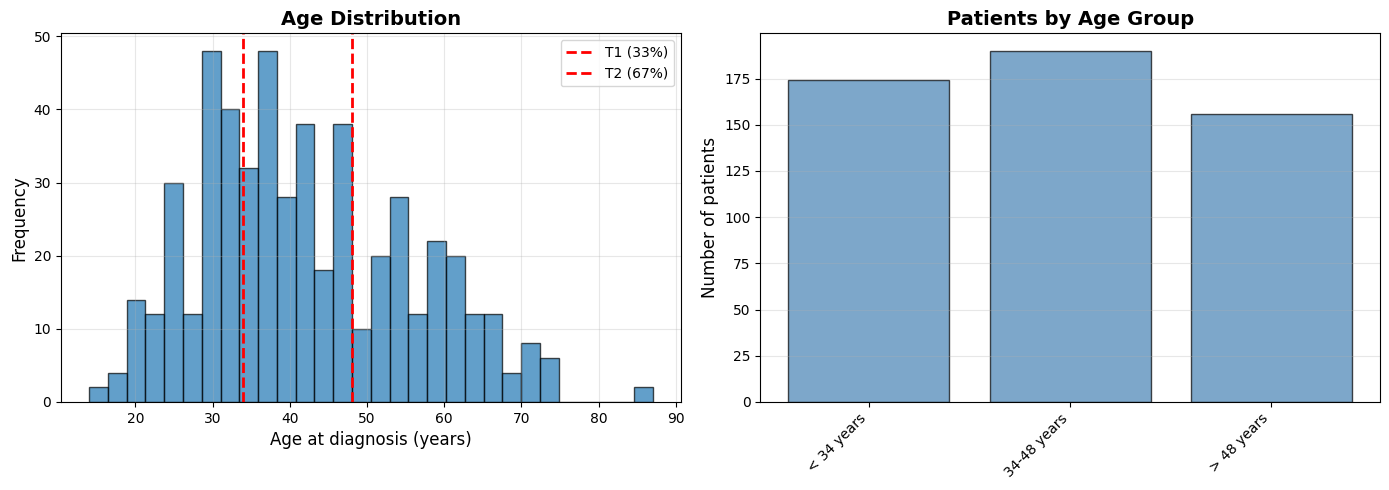

In [53]:
# Create age groups
age_data = clinical_df_sa['age_at_index'].dropna()
q33 = age_data.quantile(0.33)
q67 = age_data.quantile(0.67)
age_bins = [age_data.min()-1, q33, q67, age_data.max()+1]
age_labels = [
    f'< {q33:.0f} years',
    f'{q33:.0f}-{q67:.0f} years',
    f'> {q67:.0f} years'
]

clinical_df_sa['age_group'] = pd.cut(clinical_df_sa['age_at_index'], bins=age_bins, labels=age_labels, include_lowest=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(age_data, bins=30, edgecolor='black', alpha=0.7)
for q, label in zip([q33, q67], ['T1 (33%)', 'T2 (67%)']):
    axes[0].axvline(q, color='red', linestyle='--', linewidth=2, label=label)
axes[0].set_xlabel('Age at diagnosis (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

age_counts = clinical_df_sa['age_group'].value_counts().sort_index()
axes[1].bar(range(len(age_counts)), age_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(age_counts)))
axes[1].set_xticklabels(age_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Number of patients', fontsize=12)
axes[1].set_title('Patients by Age Group', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout() 
plt.savefig(os.path.join(output_dir_sa, f'{dataset}_age_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()  


34-48 years: Median survival = 7.9 years

< 34 years: Median survival = 11.2 years

> 48 years: Median survival = 5.5 years
\Log-Rank test: p=0.0000


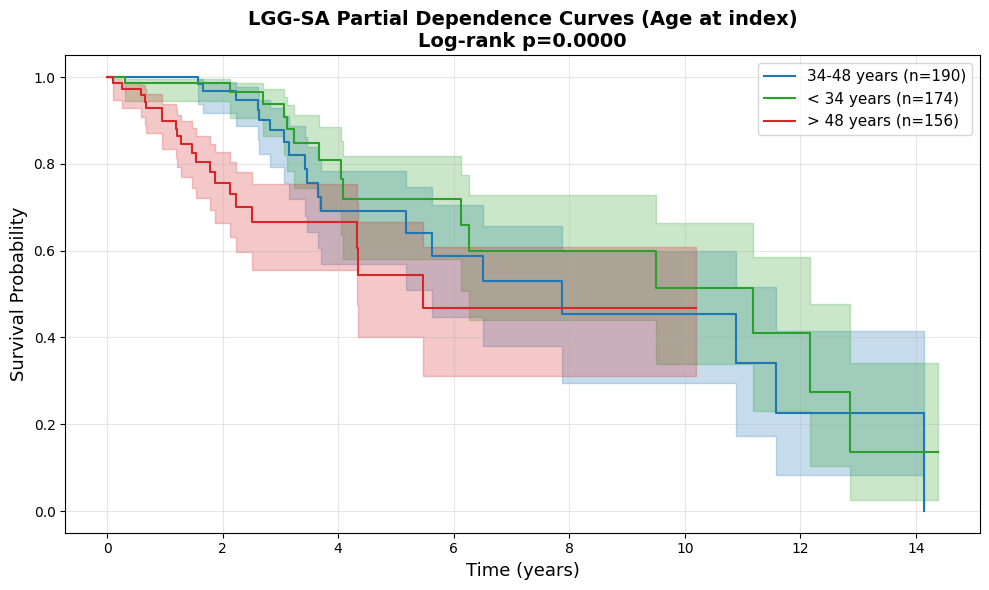

In [54]:
df_km_age = clinical_df_sa[['time', 'event', 'age_group']].dropna()
df_km_age['event_km'] = (df_km_age['event'] > 0).astype(int)
age_groups_sorted = sorted(df_km_age['age_group'].unique())
kmfs_age = {}

fig, ax = plt.subplots(figsize=(10, 6))

# Green for youngest (best prognosis), blue for middle, red for oldest (worst)
color_map = {}
for i, age_grp in enumerate(age_groups_sorted):
    if i == 0:
        color_map[age_grp] = 'tab:blue' 
    elif i == len(age_groups_sorted) - 1:
        color_map[age_grp] = 'tab:red' 
    else:
        color_map[age_grp] = 'tab:green'  

for age_grp in age_groups_sorted:
    mask = df_km_age['age_group'] == age_grp
    T = df_km_age.loc[mask, 'time'] / 365.25
    E = df_km_age.loc[mask, 'event_km']
    kmf = KaplanMeierFitter()
    kmf.fit(T, E, label=f'{age_grp} (n={len(T)})')
    kmfs_age[age_grp] = kmf
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color_map[age_grp])
    median_survival = kmf.median_survival_time_
    print(f"\n{age_grp}: Median survival = {median_survival:.1f} years")

results_age = multivariate_logrank_test(df_km_age['time'], df_km_age['age_group'], df_km_age['event_km'])

# Store p-value for combined plot
pval_age_stored = results_age.p_value
stat_age_stored = results_age.test_statistic
print(f"\Log-Rank test: p={results_age.p_value:.4f}")

ax.set_xlabel('Time (years)', fontsize=13)
ax.set_ylabel('Survival Probability', fontsize=13)
ax.set_title(f'{dataset.upper()}-SA Partial Dependence Curves (Age at index)\nLog-rank p={results_age.p_value:.4f}', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(output_dir_sa, f'{dataset}_km_age.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. Gender

p-value: 0.4239


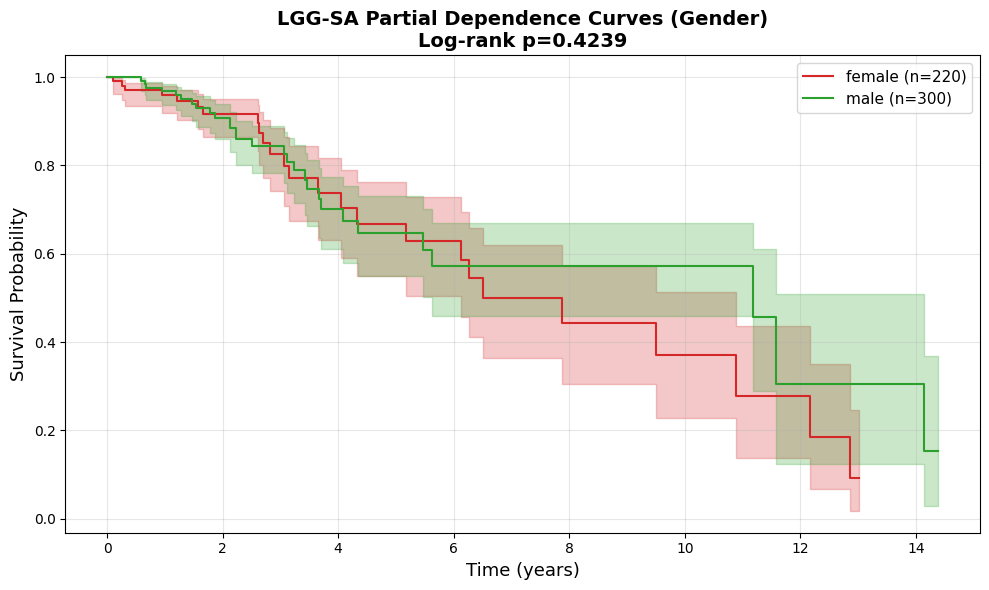

In [55]:
# Prepare data (usando datos SA)
df_km = clinical_df_sa[['time', 'event', 'gender']].dropna()
df_km['event_km'] = (df_km['event'] > 0).astype(int)
gender_groups = df_km['gender'].unique()
kmfs = {}

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'male': 'tab:green', 'female': 'tab:red'}
if 'Male' in gender_groups:
    colors = {'Male':'tab:green', 'Female': 'tab:red'}

for gender in sorted(gender_groups):
    mask = df_km['gender'] == gender
    T = df_km.loc[mask, 'time'] / 365.25  # Convert to years
    E = df_km.loc[mask, 'event_km']
    kmf = KaplanMeierFitter()
    kmf.fit(T, E, label=f'{gender} (n={len(T)})')
    kmfs[gender] = kmf
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors.get(gender, 'gray'))
    median_survival = kmf.median_survival_time_

# Log-rank test
results = multivariate_logrank_test(df_km['time'], df_km['gender'], df_km['event_km'])

# Store p-value for combined plot
pval_gender_stored = results.p_value
stat_gender_stored = results.test_statistic
print(f"p-value: {results.p_value:.4f}")

ax.set_xlabel('Time (years)', fontsize=13)
ax.set_ylabel('Survival Probability', fontsize=13)
ax.set_title(f'{dataset.upper()}-SA Partial Dependence Curves (Gender)\nLog-rank p={results.p_value:.4f}', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(output_dir_sa, f'{dataset}_km_gender.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. TP53 CNV Analysis

Load real Copy Number Variation (CNV) data for TP53 gene:
- **Amplified**: Copy number > 2
- **Non-amplified**: Copy number ≤ 2 (Neutral or Deleted)

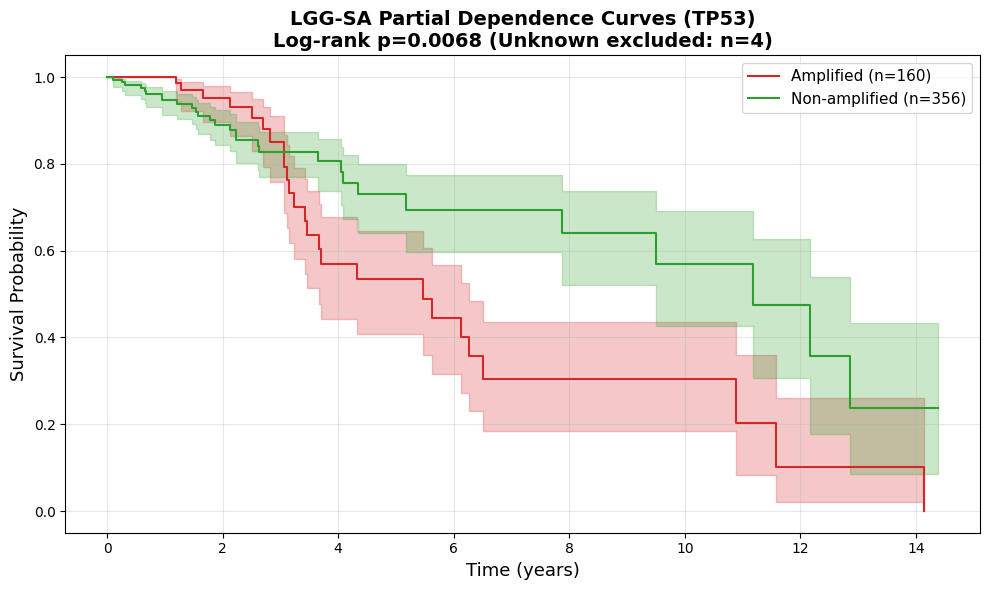

In [56]:
# Load CNV data
symbols_file_path = f'../../data_download/Frequently_mutated_genes/frequently-mutated-genes_{dataset}.tsv'
cnv_file_path = f'../data_preprocessing/raw_data/omic_data/cnv/{dataset}/consolidated_segments_by_gene.tsv'
sample_sheet_path = f'../../data_download/Sample_sheets/{dataset.upper()}/gdc_sample_sheet.cnv.tsv'
clinical_cr_path = f'../../data_download/clinical_PANCAN/filtered{dataset.upper()}_sample_sheet.processed_with_cr.tsv'
df_symbols = pd.read_csv(symbols_file_path, sep='\t')
df_sample = pd.read_csv(sample_sheet_path, sep='\t')
file_to_submitter = dict(zip(df_sample['File ID'], df_sample['Case ID']))
df_clinical_cr = pd.read_csv(clinical_cr_path, sep='\t')
submitter_to_uuid = dict(zip(df_clinical_cr['case_submitter_id'], df_clinical_cr['case_id']))

# Gene of interest
gene_of_interest = 'TP53'
def get_gene_id(symbol_to_find):
    result = df_symbols[df_symbols['symbol'] == symbol_to_find]
    if not result.empty:
        return result['gene_id'].values[0]
    return None
gene_id = get_gene_id(gene_of_interest)

if gene_id is None:
    clinical_df_sa['TP53_mutated'] = 'Unknown'
else:
    df_cnv = pd.read_csv(cnv_file_path, sep='\t')
    gene_cnv_row = df_cnv[df_cnv.iloc[:, 0] == gene_id]
    if gene_cnv_row.empty:
        clinical_df_sa['TP53_mutated'] = 'Unknown'
    else:
        cnv_values = gene_cnv_row.iloc[0, 1:].values
        file_ids = df_cnv.columns[1:].tolist()  # File IDs from CNV file
        cnv_dict_by_file = dict(zip(file_ids, cnv_values))
        cnv_series = pd.Series(cnv_values)

        # Map CNV status to clinical patients: UUID -> Submitter ID -> File ID -> CNV status
        def map_cnv_status(case_id_uuid):
            submitter_ids = [sub for sub, uuid in submitter_to_uuid.items() if uuid == case_id_uuid]
            if len(submitter_ids) > 0:
                submitter_id = submitter_ids[0]
                file_ids_for_case = [fid for fid, sub in file_to_submitter.items() if sub == submitter_id]

                if len(file_ids_for_case) > 0:
                    file_id = file_ids_for_case[0]  
                    if file_id in cnv_dict_by_file:
                        status = cnv_dict_by_file[file_id]
                        if status == 'Amplified':
                            return 'Amplified'
                        elif status in ['Neutral', 'Deleted']:
                            return 'Non-amplified'
            return 'Unknown'
        clinical_df_sa['TP53_mutated'] = clinical_df_sa['case_id'].apply(map_cnv_status)


# Plot
df_km_tp53 = clinical_df_sa.copy()
df_km_tp53['event_km'] = (df_km_tp53['event'] > 0).astype(int)

n_unknown = (df_km_tp53['TP53_mutated'] == 'Unknown').sum()
df_km_tp53 = df_km_tp53[df_km_tp53['TP53_mutated'] != 'Unknown'].copy()
df_km_tp53 = df_km_tp53[['time', 'event_km', 'TP53_mutated']].dropna()

if len(df_km_tp53['TP53_mutated'].unique()) >= 2 and len(df_km_tp53) >= 10:
    kmfs_tp53 = {}
    fig, ax = plt.subplots(figsize=(10, 6))
    # Green for Non-amplified (better prognosis), Red for Amplified (worse prognosis)
    colors_tp53 = {'Amplified': 'tab:red', 'Non-amplified': 'tab:green'}
    for tp53_status in ['Amplified', 'Non-amplified']:
        mask = df_km_tp53['TP53_mutated'] == tp53_status
        if mask.sum() == 0:
            continue

        T = df_km_tp53.loc[mask, 'time'] / 365.25
        E = df_km_tp53.loc[mask, 'event_km']
        kmf = KaplanMeierFitter()
        kmf.fit(T, E, label=f'{tp53_status} (n={len(T)})')
        kmfs_tp53[tp53_status] = kmf
        kmf.plot_survival_function(ax=ax, ci_show=True, color=colors_tp53[tp53_status])
        median = kmf.median_survival_time_

    results_tp53 = multivariate_logrank_test(df_km_tp53['time'], df_km_tp53['TP53_mutated'], df_km_tp53['event_km'])

   

    # p-value 
    pval_tp53_stored = results_tp53.p_value
    stat_tp53_stored = results_tp53.test_statistic

    ax.set_xlabel('Time (years)', fontsize=13)
    ax.set_ylabel('Survival Probability', fontsize=13)
    ax.set_title(f'{dataset.upper()}-SA Partial Dependence Curves (TP53)\nLog-rank p={results_tp53.p_value:.4f} (Unknown excluded: n={n_unknown})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_sa, f'{dataset}_km_tp53.png'), dpi=300, bbox_inches='tight')
    plt.show()


# 4. Partial Dependence Plots

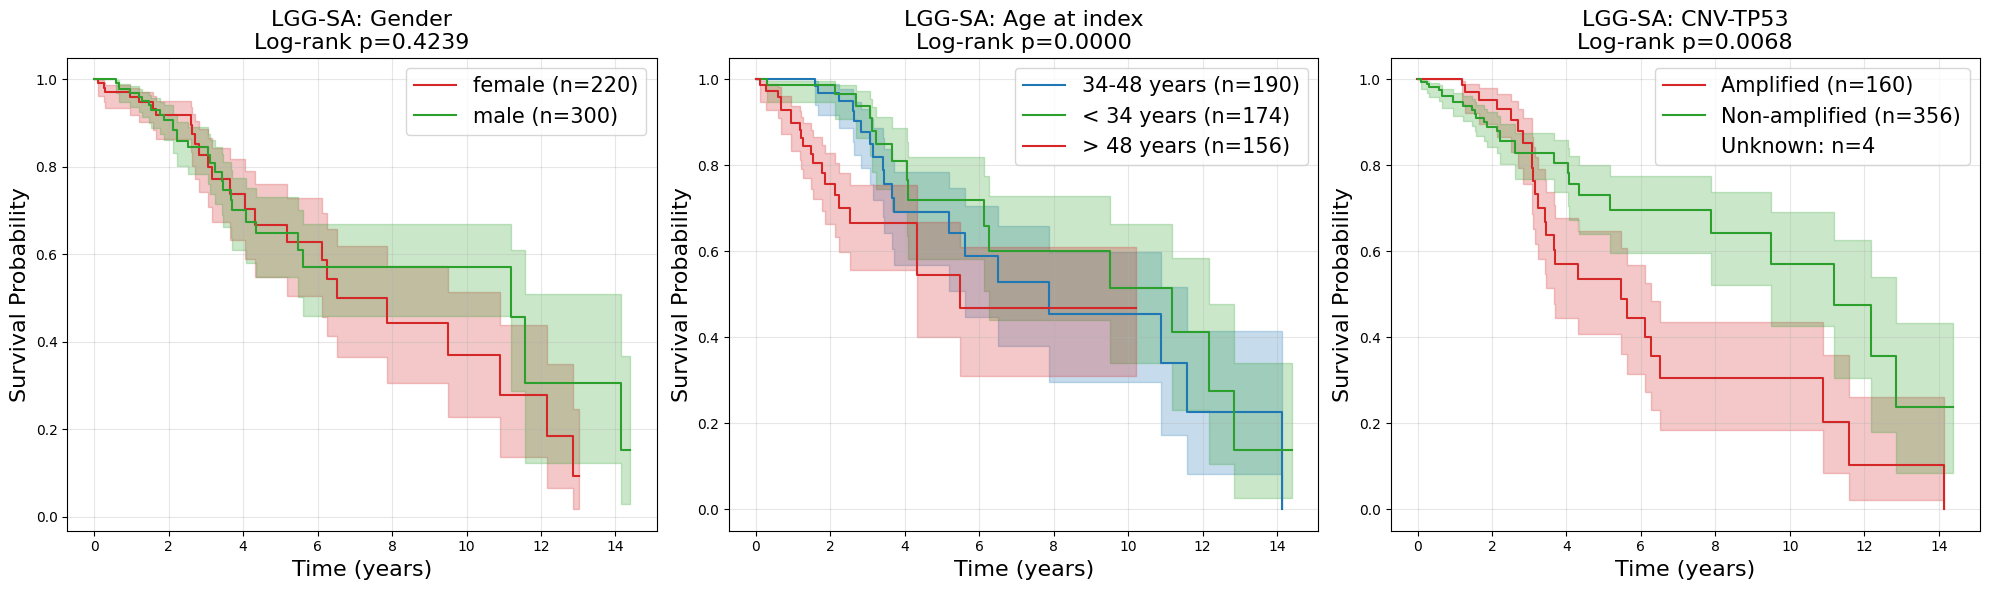

In [57]:
# p-values 
pval_gender = pval_gender_stored if 'pval_gender_stored' in dir() else None
pval_age = pval_age_stored if 'pval_age_stored' in dir() else None
pval_tp53 = pval_tp53_stored if 'pval_tp53_stored' in dir() else None


# Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Gender 
ax = axes[0]
for gender in sorted(kmfs.keys()):
    kmf = kmfs[gender]
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors.get(gender, 'gray'))

ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Survival Probability', fontsize=16)
ax.set_title(f'{dataset.upper()}-SA: Gender\nLog-rank p={pval_gender:.4f}', 
             fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=15)

# Plot 2: Age 
ax = axes[1]
color_map = {}
for i, age_grp in enumerate(age_groups_sorted):
    if i == 0:
        color_map[age_grp] ='tab:blue'   
    elif i == len(age_groups_sorted) - 1:
        color_map[age_grp] = 'tab:red'   
    else:
        color_map[age_grp] =  'tab:green'  

for age_grp in age_groups_sorted:
    kmf = kmfs_age[age_grp]
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color_map[age_grp])

ax.set_xlabel('Time (years)', fontsize=16)
ax.set_ylabel('Survival Probability', fontsize=16)
ax.set_title(f'{dataset.upper()}-SA: Age at index\nLog-rank p={pval_age:.4f}', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=15)

# Plot 3: TP53 
ax = axes[2]
if len(kmfs_tp53) > 0 and pval_tp53 is not None:
    for tp53_status in ['Amplified', 'Non-amplified']:
        if tp53_status in kmfs_tp53:
            kmf = kmfs_tp53[tp53_status]
            kmf.plot_survival_function(ax=ax, ci_show=True, color=colors_tp53[tp53_status])
    
    ax.set_xlabel('Time (years)', fontsize=16)
    ax.set_ylabel('Survival Probability', fontsize=16)
    ax.set_title(f'{dataset.upper()}-SA: CNV-TP53\nLog-rank p={results_tp53.p_value:.4f}', fontsize=16)
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels() 
    handles.append(Rectangle((0, 0), 0, 0, alpha=0))
    labels.append(f'Unknown: n={n_unknown}')
    ax.legend(handles, labels, loc='best', fontsize=15)
else:
    ax.text(0.5, 0.5, 'TP53 data not available', ha='center', va='center', fontsize=15, transform=ax.transAxes)
    ax.set_title(f'{dataset.upper()}-SA: CNV-TP53', fontsize=16)

plt.tight_layout()
plt.savefig(os.path.join(output_dir_sa, f'{dataset}_km_combined.png'), dpi=300, bbox_inches='tight')
plt.show()